# _Healthcare Patient Records Dataset_

## _Introduction_

The healthcare sector generates a large amount of data related to patient records, 
diagnoses, treatments, and recovery outcomes. Analyzing such data helps in understanding 
patterns in diseases, treatment costs, patient demographics, and recovery trends. Data 
analysis techniques allow healthcare professionals and researchers to identify relationships 
between different health indicators and improve decision-making in medical care.

The objective of this project is to perform Exploratory Data Analysis (EDA) on a 
synthetically generated healthcare patient records dataset, followed by applying Machine 
Learning models to predict hospital admission. The dataset was created using Python's NumPy 
library with a fixed random seed to ensure reproducibility. The analysis focuses on 
identifying trends in patient age, BMI, blood pressure, glucose levels, hospital visits, 
diagnosis types, treatment costs, and recovery days.

Statistical methods and data visualization techniques were applied using Python libraries 
such as Pandas, NumPy, Matplotlib, Seaborn, and Plotly. 

Note: Since this is a synthetically generated dataset, the variables are not correlated 
by design. Therefore, the findings should not be interpreted as medically meaningful, and 
the ML model performance reflects the nature of the data rather than real-world patterns.

## _DataSet Structure_

The dataset used in this project contains information about patient health indicators, medical diagnoses, and treatment outcomes. Each row in the dataset represents an individual patient's record, while the columns represent various medical and demographic attributes.

Columns in this Dataset:
| Column Name         | Description                                                                                           |
| ------------------- | ----------------------------------------------------------------------------------------------------- |
| **patient_id**      | Unique identification number assigned to each patient.                                                |
| **age**             | Age of the patient in years.                                                                          |
| **bmi**             | Body Mass Index of the patient, which indicates body fat based on height and weight.                  |
| **glucose_level**   | Blood glucose level of the patient.                                                                   |
| **hospital_visits** | Number of times the patient has visited the hospital.                                                 |
| **diagnosis**       | Medical condition diagnosed for the patient (e.g., Diabetes, Hypertension, Heart Disease, or Normal). |
| **treatment_cost**  | Total cost incurred for the patient’s treatment.                                                      |
| **recovery_days**   | Number of days taken for the patient to recover.                                                      |
| **severity_score**  | A calculated metric indicating the severity of the patient’s health condition.                        |
| **age_group**       | Categorized age group of the patient (for example: Young, Middle-aged, Senior).                       |

The dataset is analyzed to explore relationships between patient demographics, health conditions, treatment costs, and recovery outcomes.

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings("ignore")

In [36]:
np.random.seed(42)  #fix the randomness generated by numpy

n = 7658    #number of rows

df = pd.DataFrame({
    "Patient ID": range(1,n+1),
    
    "Age": np.random.randint(18,85, size=n),
    
    "gender": np.random.choice(
        ['Male', 'Female'],
        size=n,
        p=[0.52, 0.48]),

    "BMI": np.round(
        np.random.normal(loc=26, scale=4.5, size=n),
        1),
        
    "Blood Pressure": np.random.randint(85,200,size=n),

    "Glucose Level": np.random.randint(65, 260, size=n),

    "diagnosis": np.random.choice(
        ['Diabetes', 'Hypertension', 'Heart Disease', 'Normal'],
        size=n,
        p=[0.3, 0.25, 0.15, 0.3]
    ),

    "hospital_visits": np.random.randint(0, 20, size=n),

    "recovery_days": np.random.choice(
        [5, 10, 15, 20, np.nan],
        size=n,
        p=[0.25, 0.25, 0.2, 0.2, 0.1]
    ),

    "treatment_cost": np.random.randint(5000, 200000, size=n),

    "admitted": np.random.binomial(1, 0.6, size=n),

    "visit_month": np.random.choice(
        ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
         'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec'],
        size=n
    )
})
        

In [37]:
df

,Patient ID,Age,gender,BMI,Blood Pressure,Glucose Level,diagnosis,hospital_visits,recovery_days,treatment_cost,admitted,visit_month
0,1,69,Female,31.9,98,150,Normal,14,15.0,10485,1,Jan
1,2,32,Male,23.0,92,257,Diabetes,8,NaN,98728,1,Jul
2,3,78,Male,19.6,108,84,Diabetes,5,15.0,195103,0,Mar
3,4,38,Female,25.7,170,248,Diabetes,10,5.0,32626,1,Dec
4,5,41,Male,24.4,188,246,Diabetes,5,10.0,147870,1,Jan
...,...,...,...,...,...,...,...,...,...,...,...,...
7653,7654,77,Male,26.4,85,198,Diabetes,12,5.0,49268,1,Jun
7654,7655,30,Male,17.0,143,235,Hypertension,17,15.0,103128,1,Sep
7655,7656,18,Female,18.1,147,241,Hypertension,17,10.0,49449,0,Feb
7656,7657,82,Female,34.7,163,73,Normal,16,5.0,95316,1,Feb


## _Data Overview_

In [38]:
df.head() # to display first 5 rows 

,Patient ID,Age,gender,BMI,Blood Pressure,Glucose Level,diagnosis,hospital_visits,recovery_days,treatment_cost,admitted,visit_month
0,1,69,Female,31.9,98,150,Normal,14,15.0,10485,1,Jan
1,2,32,Male,23.0,92,257,Diabetes,8,NaN,98728,1,Jul
2,3,78,Male,19.6,108,84,Diabetes,5,15.0,195103,0,Mar
3,4,38,Female,25.7,170,248,Diabetes,10,5.0,32626,1,Dec
4,5,41,Male,24.4,188,246,Diabetes,5,10.0,147870,1,Jan


In [39]:
df.info() # basic information about the data

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7658 entries, 0 to 7657
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Patient ID       7658 non-null   int64  
 1   Age              7658 non-null   int32  
 2   gender           7658 non-null   object 
 3   BMI              7658 non-null   float64
 4   Blood Pressure   7658 non-null   int32  
 5   Glucose Level    7658 non-null   int32  
 6   diagnosis        7658 non-null   object 
 7   hospital_visits  7658 non-null   int32  
 8   recovery_days    6917 non-null   float64
 9   treatment_cost   7658 non-null   int32  
 10  admitted         7658 non-null   int32  
 11  visit_month      7658 non-null   object 
dtypes: float64(2), int32(6), int64(1), object(3)
memory usage: 538.6+ KB


In [40]:
df.shape  #number of rows and columns

(7658, 12)

In [41]:
df.isnull().sum()  # checking for null values

Patient ID           0
Age                  0
gender               0
BMI                  0
Blood Pressure       0
Glucose Level        0
diagnosis            0
hospital_visits      0
recovery_days      741
treatment_cost       0
admitted             0
visit_month          0
dtype: int64

## _Data Transformation and Cleaning_

In [42]:
df.columns = df.columns.str.lower()  #converting the column names into lower case.df
df

,patient id,age,gender,bmi,blood pressure,glucose level,diagnosis,hospital_visits,recovery_days,treatment_cost,admitted,visit_month
0,1,69,Female,31.9,98,150,Normal,14,15.0,10485,1,Jan
1,2,32,Male,23.0,92,257,Diabetes,8,NaN,98728,1,Jul
2,3,78,Male,19.6,108,84,Diabetes,5,15.0,195103,0,Mar
3,4,38,Female,25.7,170,248,Diabetes,10,5.0,32626,1,Dec
4,5,41,Male,24.4,188,246,Diabetes,5,10.0,147870,1,Jan
...,...,...,...,...,...,...,...,...,...,...,...,...
7653,7654,77,Male,26.4,85,198,Diabetes,12,5.0,49268,1,Jun
7654,7655,30,Male,17.0,143,235,Hypertension,17,15.0,103128,1,Sep
7655,7656,18,Female,18.1,147,241,Hypertension,17,10.0,49449,0,Feb
7656,7657,82,Female,34.7,163,73,Normal,16,5.0,95316,1,Feb


In [43]:
df.columns = df.columns.str.replace(' ','_')  #removing spaces from the column names
df

,patient_id,age,gender,bmi,blood_pressure,glucose_level,diagnosis,hospital_visits,recovery_days,treatment_cost,admitted,visit_month
0,1,69,Female,31.9,98,150,Normal,14,15.0,10485,1,Jan
1,2,32,Male,23.0,92,257,Diabetes,8,NaN,98728,1,Jul
2,3,78,Male,19.6,108,84,Diabetes,5,15.0,195103,0,Mar
3,4,38,Female,25.7,170,248,Diabetes,10,5.0,32626,1,Dec
4,5,41,Male,24.4,188,246,Diabetes,5,10.0,147870,1,Jan
...,...,...,...,...,...,...,...,...,...,...,...,...
7653,7654,77,Male,26.4,85,198,Diabetes,12,5.0,49268,1,Jun
7654,7655,30,Male,17.0,143,235,Hypertension,17,15.0,103128,1,Sep
7655,7656,18,Female,18.1,147,241,Hypertension,17,10.0,49449,0,Feb
7656,7657,82,Female,34.7,163,73,Normal,16,5.0,95316,1,Feb


In [44]:
#converting columns to numeric
numeric_cols = [
    'age', 'bmi', 'blood_pressure',
    'glucose_level', 'hospital_visits', 'recovery_days', 'treatment_cost'
]
df[numeric_cols] = df[numeric_cols].apply(pd.to_numeric)
df

,patient_id,age,gender,bmi,blood_pressure,glucose_level,diagnosis,hospital_visits,recovery_days,treatment_cost,admitted,visit_month
0,1,69,Female,31.9,98,150,Normal,14,15.0,10485,1,Jan
1,2,32,Male,23.0,92,257,Diabetes,8,NaN,98728,1,Jul
2,3,78,Male,19.6,108,84,Diabetes,5,15.0,195103,0,Mar
3,4,38,Female,25.7,170,248,Diabetes,10,5.0,32626,1,Dec
4,5,41,Male,24.4,188,246,Diabetes,5,10.0,147870,1,Jan
...,...,...,...,...,...,...,...,...,...,...,...,...
7653,7654,77,Male,26.4,85,198,Diabetes,12,5.0,49268,1,Jun
7654,7655,30,Male,17.0,143,235,Hypertension,17,15.0,103128,1,Sep
7655,7656,18,Female,18.1,147,241,Hypertension,17,10.0,49449,0,Feb
7656,7657,82,Female,34.7,163,73,Normal,16,5.0,95316,1,Feb


In [45]:
# filling in missing values by median.
df['recovery_days'].fillna(df['recovery_days'].median(), inplace=True)
df

,patient_id,age,gender,bmi,blood_pressure,glucose_level,diagnosis,hospital_visits,recovery_days,treatment_cost,admitted,visit_month
0,1,69,Female,31.9,98,150,Normal,14,15.0,10485,1,Jan
1,2,32,Male,23.0,92,257,Diabetes,8,10.0,98728,1,Jul
2,3,78,Male,19.6,108,84,Diabetes,5,15.0,195103,0,Mar
3,4,38,Female,25.7,170,248,Diabetes,10,5.0,32626,1,Dec
4,5,41,Male,24.4,188,246,Diabetes,5,10.0,147870,1,Jan
...,...,...,...,...,...,...,...,...,...,...,...,...
7653,7654,77,Male,26.4,85,198,Diabetes,12,5.0,49268,1,Jun
7654,7655,30,Male,17.0,143,235,Hypertension,17,15.0,103128,1,Sep
7655,7656,18,Female,18.1,147,241,Hypertension,17,10.0,49449,0,Feb
7656,7657,82,Female,34.7,163,73,Normal,16,5.0,95316,1,Feb


In [46]:
# checking for outliers
numeric_cols = ['age', 'bmi', 'blood_pressure',
                'glucose_level', 'hospital_visits', 'recovery_days', 'treatment_cost'
               ]
for col in numeric_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1

    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr

    outliers = df[(df[col] < lower) |
    (df[col] > upper)]
    print(f"{col}: {outliers.shape[0]} outliers")

age: 0 outliers
bmi: 52 outliers
blood_pressure: 0 outliers
glucose_level: 0 outliers
hospital_visits: 0 outliers
recovery_days: 0 outliers
treatment_cost: 0 outliers


In [47]:
# treating outliers using capping 
q1 = df['bmi'].quantile(0.25)
q3 = df['bmi'].quantile(0.75)
iqr = q3 - q1

lower = q1 - 1.5 * iqr
upper = q3 + 1.5 * iqr

df['bmi'] = df['bmi'].clip(lower, upper)

print("Lower bound:", lower)
print("Upper bound:", upper)

Lower bound: 13.700000000000001
Upper bound: 38.5


In [48]:
df['bmi'].min(), df['bmi'].max()

(13.700000000000001, 38.5)

## _Basic Statistics_

In [49]:
df.describe()

,patient_id,age,bmi,blood_pressure,glucose_level,hospital_visits,recovery_days,treatment_cost,admitted
count,7658.000000,7658.000000,7658.000000,7658.000000,7658.000000,7658.000000,7658.000000,7658.000000,7658.000000
mean,3829.500000,51.002481,26.087125,142.232567,161.994385,9.379081,11.794202,100701.210629,0.599243
std,2210.818514,19.288158,4.491363,33.123032,56.725525,5.754257,5.299538,56574.294145,0.490084
min,1.000000,18.000000,13.700000,85.000000,65.000000,0.000000,5.000000,5017.000000,0.000000
25%,1915.250000,34.000000,23.000000,113.000000,112.000000,4.000000,10.000000,50827.000000,0.000000
50%,3829.500000,51.000000,26.100000,142.000000,162.000000,9.000000,10.000000,100643.000000,1.000000
75%,5743.750000,68.000000,29.200000,171.000000,211.000000,14.000000,15.000000,149656.500000,1.000000
max,7658.000000,84.000000,38.500000,199.000000,259.000000,19.000000,20.000000,199957.000000,1.000000


In [50]:
df.describe(include='object')

,gender,diagnosis,visit_month
count,7658,7658,7658
unique,2,4,12
top,Male,Diabetes,Jul
freq,4058,2311,681


In [51]:
# mean vs median
df[numeric_cols].agg(['mean','median'])

,age,bmi,blood_pressure,glucose_level,hospital_visits,recovery_days,treatment_cost
mean,51.002481,26.087125,142.232567,161.994385,9.379081,11.794202,100701.210629
median,51.000000,26.100000,142.000000,162.000000,9.000000,10.000000,100643.000000


In [52]:
# diagnose-wise cost
df.groupby('diagnosis')['treatment_cost'].mean()

diagnosis
Diabetes         100988.271311
Heart Disease     99638.714414
Hypertension      99607.351172
Normal           101878.266755
Name: treatment_cost, dtype: float64

In [53]:
# correlation matrix
corr_matrix=df[numeric_cols].corr()
corr_matrix

,age,bmi,blood_pressure,glucose_level,hospital_visits,recovery_days,treatment_cost
age,1.000000,-0.000757,0.003573,-0.007583,0.007260,0.007725,-0.003733
bmi,-0.000757,1.000000,0.003169,-0.010389,-0.007088,0.019003,0.022661
blood_pressure,0.003573,0.003169,1.000000,0.009861,-0.020878,-0.006957,-0.011025
glucose_level,-0.007583,-0.010389,0.009861,1.000000,-0.002862,-0.006246,-0.012274
hospital_visits,0.007260,-0.007088,-0.020878,-0.002862,1.000000,-0.008688,0.003041
recovery_days,0.007725,0.019003,-0.006957,-0.006246,-0.008688,1.000000,-0.011506
treatment_cost,-0.003733,0.022661,-0.011025,-0.012274,0.003041,-0.011506,1.000000


## _Feature Engineering_

In [54]:
# Adding a new column 'severity_score'
df['severity_score'] = (
    (df['glucose_level'] > 140).astype(int) +
    (df['blood_pressure'] > 140).astype(int) +
    (df['bmi'] > 30).astype(int)
)
df

,patient_id,age,gender,bmi,blood_pressure,glucose_level,diagnosis,hospital_visits,recovery_days,treatment_cost,admitted,visit_month,severity_score
0,1,69,Female,31.9,98,150,Normal,14,15.0,10485,1,Jan,2
1,2,32,Male,23.0,92,257,Diabetes,8,10.0,98728,1,Jul,1
2,3,78,Male,19.6,108,84,Diabetes,5,15.0,195103,0,Mar,0
3,4,38,Female,25.7,170,248,Diabetes,10,5.0,32626,1,Dec,2
4,5,41,Male,24.4,188,246,Diabetes,5,10.0,147870,1,Jan,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...
7653,7654,77,Male,26.4,85,198,Diabetes,12,5.0,49268,1,Jun,1
7654,7655,30,Male,17.0,143,235,Hypertension,17,15.0,103128,1,Sep,2
7655,7656,18,Female,18.1,147,241,Hypertension,17,10.0,49449,0,Feb,2
7656,7657,82,Female,34.7,163,73,Normal,16,5.0,95316,1,Feb,2


In [55]:
# segregating age groups
df['age_group'] = pd.cut(
    df['age'],
    bins=[17, 30, 45, 60, 90],
    labels=['Young Adult', 'Adult', 'Middle Aged', 'Senior']
)
df

,patient_id,age,gender,bmi,blood_pressure,glucose_level,diagnosis,hospital_visits,recovery_days,treatment_cost,admitted,visit_month,severity_score,age_group
0,1,69,Female,31.9,98,150,Normal,14,15.0,10485,1,Jan,2,Senior
1,2,32,Male,23.0,92,257,Diabetes,8,10.0,98728,1,Jul,1,Adult
2,3,78,Male,19.6,108,84,Diabetes,5,15.0,195103,0,Mar,0,Senior
3,4,38,Female,25.7,170,248,Diabetes,10,5.0,32626,1,Dec,2,Adult
4,5,41,Male,24.4,188,246,Diabetes,5,10.0,147870,1,Jan,2,Adult
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7653,7654,77,Male,26.4,85,198,Diabetes,12,5.0,49268,1,Jun,1,Senior
7654,7655,30,Male,17.0,143,235,Hypertension,17,15.0,103128,1,Sep,2,Young Adult
7655,7656,18,Female,18.1,147,241,Hypertension,17,10.0,49449,0,Feb,2,Young Adult
7656,7657,82,Female,34.7,163,73,Normal,16,5.0,95316,1,Feb,2,Senior


In [56]:
# High-risk patients who are admitted 
high_risk_patients = df.query(
    "severity_score >=2 and admitted == 1"
)
high_risk_patients.head()

,patient_id,age,gender,bmi,blood_pressure,glucose_level,diagnosis,hospital_visits,recovery_days,treatment_cost,admitted,visit_month,severity_score,age_group
0,1,69,Female,31.9,98,150,Normal,14,15.0,10485,1,Jan,2,Senior
3,4,38,Female,25.7,170,248,Diabetes,10,5.0,32626,1,Dec,2,Adult
4,5,41,Male,24.4,188,246,Diabetes,5,10.0,147870,1,Jan,2,Adult
8,9,19,Female,17.7,191,153,Hypertension,5,5.0,146492,1,Mar,2,Young Adult
9,10,47,Female,24.0,147,208,Normal,19,5.0,33525,1,Mar,2,Middle Aged


In [57]:
# Average cost by diagnosis
avg_cost_diagnosis = df.groupby('diagnosis')['treatment_cost'].mean().sort_values(ascending = False)
avg_cost_diagnosis

diagnosis
Normal           101878.266755
Diabetes         100988.271311
Heart Disease     99638.714414
Hypertension      99607.351172
Name: treatment_cost, dtype: float64

## _Exploratory Data Analysis(EDA)_

#### Global style setting

In [58]:
sns.set_style('whitegrid')
sns.set_palette('Set2')
MONTH_ORDER = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
AGE_ORDER   = ['Young Adult','Adult','Middle Aged','Senior']
DIAG_ORDER  = ['Diabetes','Hypertension','Heart Disease','Normal']

## _Univariate Analysis_

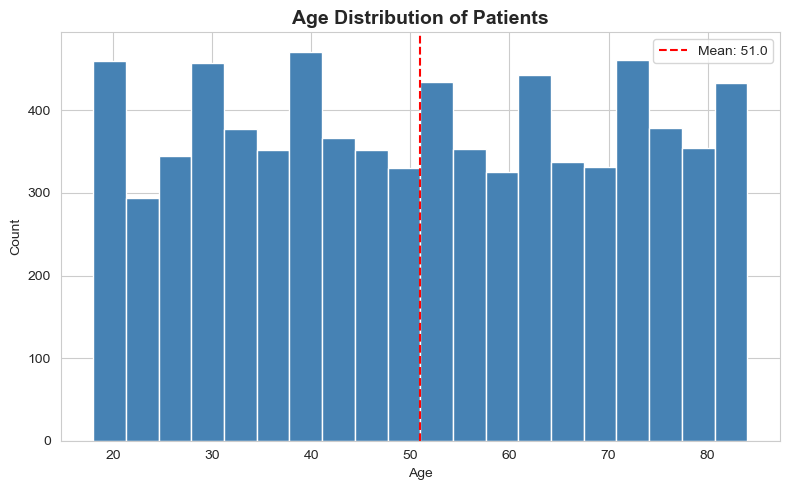

In [75]:
# Age Distribution - Histogram using matplotlib

plt.figure(figsize=(8, 5))
plt.hist(df['age'], bins=20, color='steelblue', edgecolor='white')
plt.title('Age Distribution of Patients', fontsize=14, fontweight='bold')
plt.xlabel('Age')
plt.ylabel('Count')
plt.axvline(df['age'].mean(), color='red', linestyle='--', label=f"Mean: {df['age'].mean():.1f}")
plt.legend()
plt.tight_layout()
plt.show()


*Observation-> The histogram shows the distribution of patients across different age groups. Most patients fall within the middle-age category, indicating that healthcare services are more frequently utilized by individuals in this age range.*

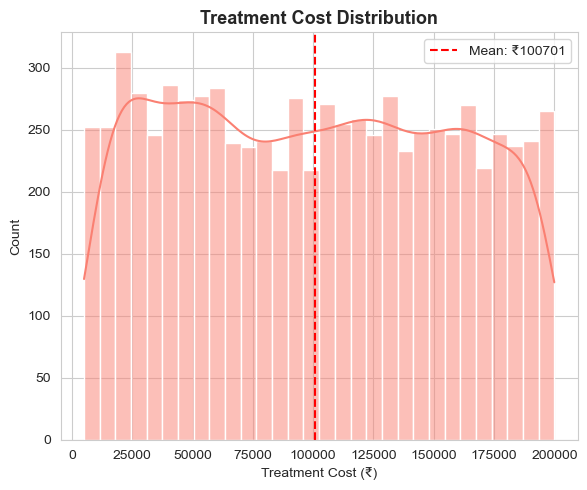

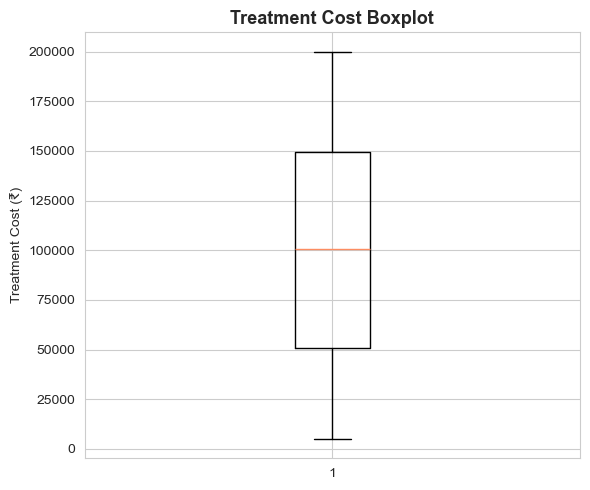

In [60]:
# Treatment cost distribution - Histogram with KDE and Boxplot

# Histogram with KDE
plt.figure(figsize=(6, 5))
sns.histplot(df['treatment_cost'], bins=30, kde=True, color='salmon')
plt.axvline(df['treatment_cost'].mean(), color='red', linestyle='--',
            label=f"Mean: ₹{df['treatment_cost'].mean():.0f}")
plt.title('Treatment Cost Distribution', fontsize=13, fontweight='bold')
plt.xlabel('Treatment Cost (₹)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

# Boxplot
plt.figure(figsize=(6, 5))
plt.boxplot(df['treatment_cost'])
plt.title('Treatment Cost Boxplot', fontsize=13, fontweight='bold')
plt.ylabel('Treatment Cost (₹)')
plt.tight_layout()
plt.show()

_Observation -> Treatment costs are widely spread between ₹5,000 and ₹2,00,000,
with a mean of approximately ₹1,00,700. The near-flat KDE curve confirms
a uniform distribution — meaning no particular cost range is more common,
which is expected in a synthetically generated dataset._

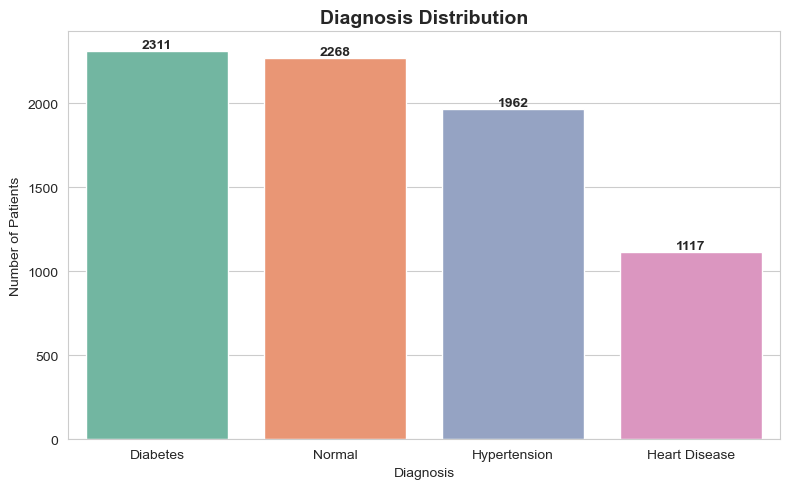

In [61]:
# Diagnosis Distribution - Count Plot

plt.figure(figsize=(8, 5))
order = df['diagnosis'].value_counts().index
ax = sns.countplot(x='diagnosis', data=df, order=order, palette='Set2')

# using loop here to label every bar
for container in ax.containers:
    ax.bar_label(container, fontweight='bold')

plt.title('Diagnosis Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

_Observation -> Diabetes is the most frequently diagnosed condition ( approx 30% of patients), followed by Normal (~ approx 30%) and Hypertension (approx 25%). Heart Disease has the
lowest count ( approx 15%), reflecting the probability weights used during data generation._

## _Bivariate Analysis_

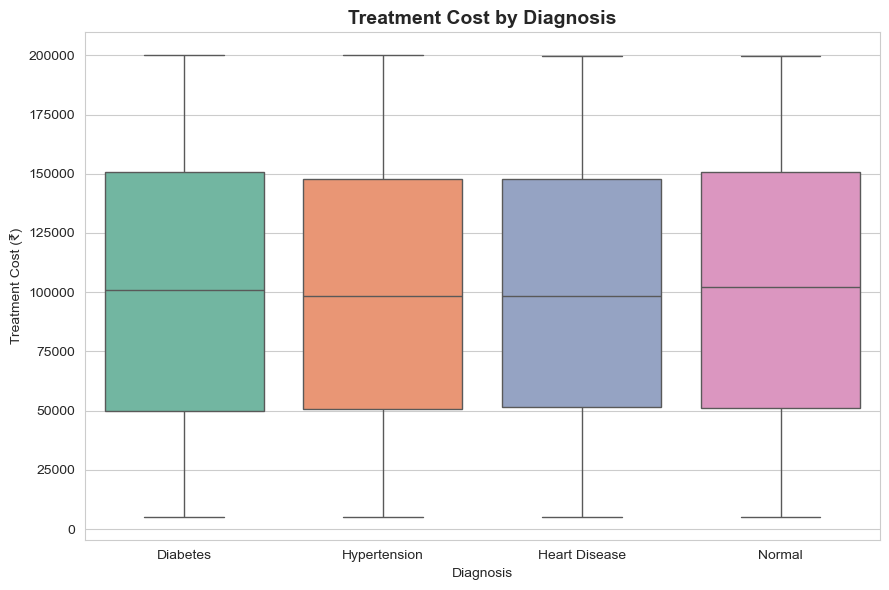

In [69]:
# Diagnosis vs Treatment Cost — Box Plot

plt.figure(figsize=(9, 6))
sns.boxplot(x='diagnosis', y='treatment_cost', data=df,
            order=['Diabetes','Hypertension','Heart Disease','Normal'], palette='Set2')
plt.title('Treatment Cost by Diagnosis', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis')
plt.ylabel('Treatment Cost (₹)')
plt.tight_layout()
plt.show()

_Observation -> Treatment costs are uniformly spread between ₹5,000 and ₹2,00,000
across all diagnosis types. No single diagnosis shows significantly higher
or lower costs, confirming that treatment costs were generated independently
of diagnosis in this synthetic dataset._

<Figure size 900x500 with 0 Axes>

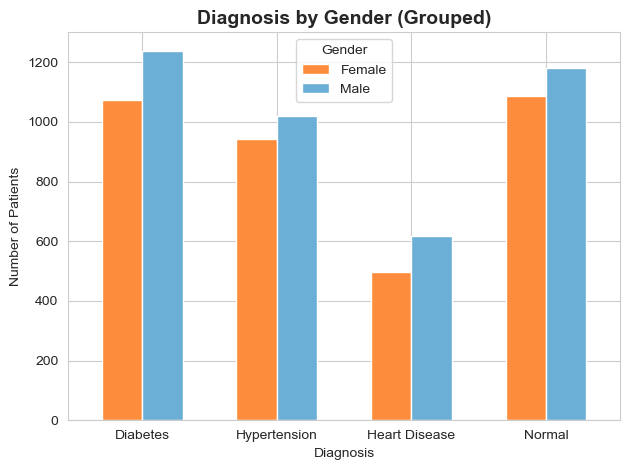

<Figure size 900x500 with 0 Axes>

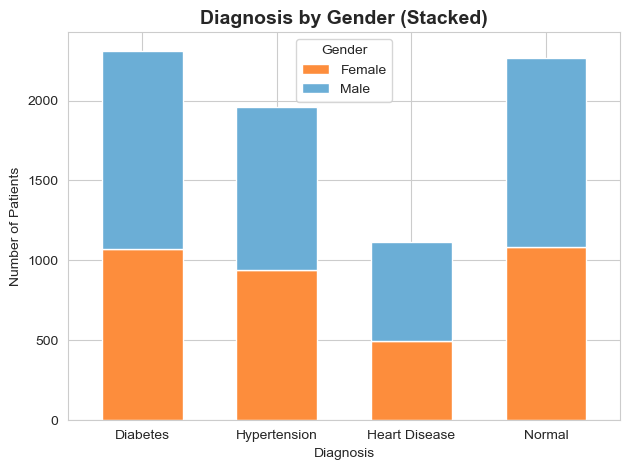

In [70]:
# Gender vs Diagnosis 

# Grouped Bar 
plt.figure(figsize=(9, 5))
diag_gender = df.groupby(['diagnosis', 'gender']).size().unstack(fill_value=0)
diag_gender.loc[['Diabetes','Hypertension','Heart Disease','Normal']].plot(
    kind='bar', color=['#fd8d3c','#6baed6'], width=0.6, edgecolor='white')
plt.title('Diagnosis by Gender (Grouped)', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

# Stacked Bar 
plt.figure(figsize=(9, 5))
diag_gender.loc[['Diabetes','Hypertension','Heart Disease','Normal']].plot(
    kind='bar', stacked=True, color=['#fd8d3c','#6baed6'], width=0.6, edgecolor='white')
plt.title('Diagnosis by Gender (Stacked)', fontsize=14, fontweight='bold')
plt.xlabel('Diagnosis')
plt.ylabel('Number of Patients')
plt.xticks(rotation=0)
plt.legend(title='Gender')
plt.tight_layout()
plt.show()



_Observation -> Both males and females show nearly identical diagnosis distributions
across all four categories. Males are slightly more represented overall (52% vs 48%),
which reflects the gender probabilities set during data generation. No diagnosis
shows a strong gender preference._

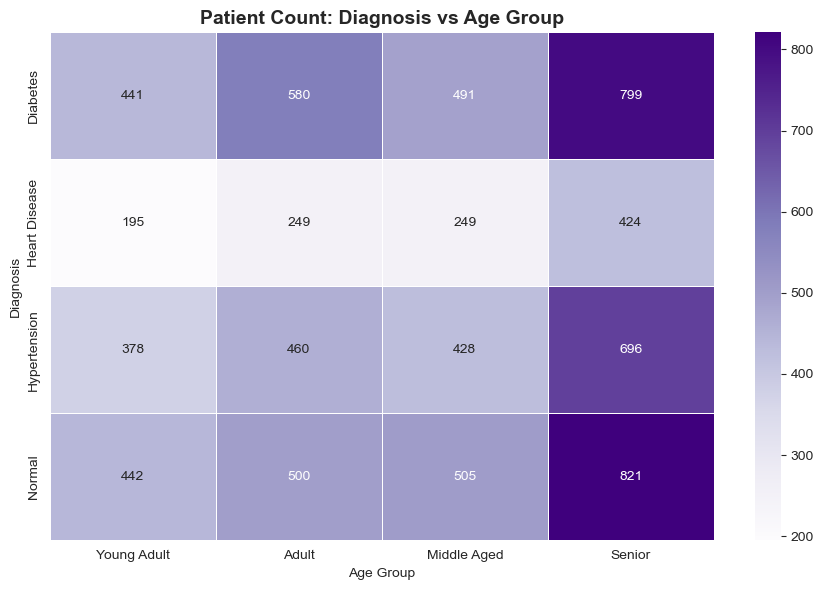

In [71]:
# Diagnosis vs Age Group- HeatMap

plt.figure(figsize=(9,6))
pivot=df.pivot_table(index='diagnosis',columns='age_group',
                     values='patient_id',aggfunc='count')
pivot=pivot.reindex(columns=['Young Adult','Adult','Middle Aged','Senior'])
sns.heatmap(pivot, annot=True, fmt='d', cmap='Purples', linewidths=0.5)
plt.title('Patient Count: Diagnosis vs Age Group', fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Diagnosis')
plt.tight_layout()
plt.show()

_Observation -> Senior patients (60–90 years) dominate every diagnosis category,
with Diabetes (799) and Normal (821) having the highest senior counts.
Young Adults have the lowest counts across all diagnoses. This pattern
reflects the uniform age distribution combined with the larger 60–90 age bin._

## _Multivariate Analysis_

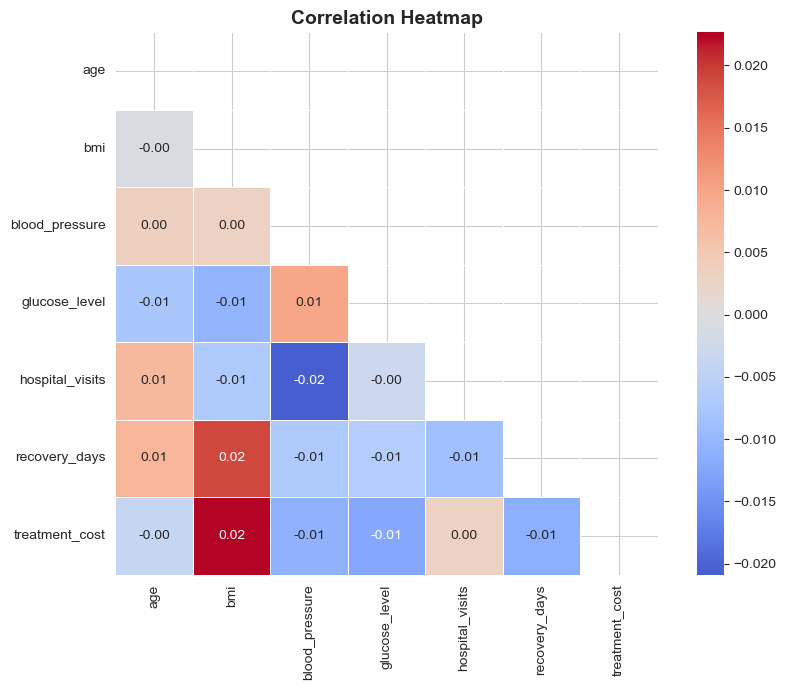

In [65]:
# Correlation Heatmap

plt.figure(figsize=(9, 7))
numeric_cols = ['age','bmi','blood_pressure','glucose_level',
                'hospital_visits','recovery_days','treatment_cost']
corr = df[numeric_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask, linewidths=0.5, square=True)
plt.title('Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

_Observation -> All correlation values lie between -0.02 and 0.02, indicating
virtually no linear relationship between any numeric variable pair.
The strongest value is bmi vs treatment_cost (0.02) and bmi vs recovery_days
(0.02), but even these are negligible. This confirms all features were
generated independently — in real healthcare data, variables like BMI,
blood pressure, and glucose level would show meaningful correlations._

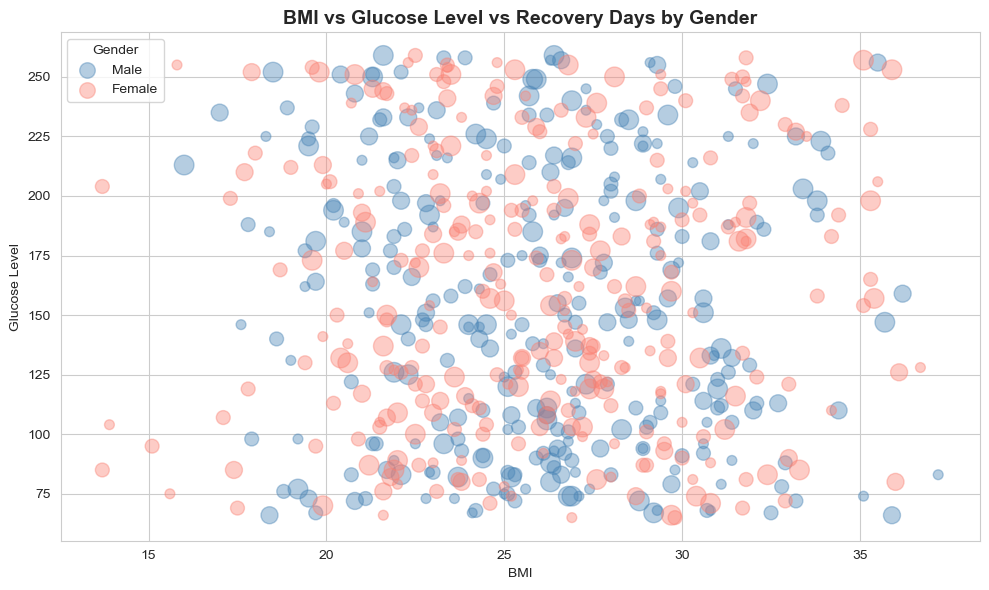

In [72]:
# Bubble Chart - BMI vs Glucose level vs Recovery Days

plt.figure(figsize=(10, 6))

# Male
male = df[df['gender'] == 'Male'].sample(300, random_state=42)
plt.scatter(male['bmi'], male['glucose_level'],
            s=male['recovery_days'] * 10,
            alpha=0.4, label='Male', color='steelblue')

# Female
female = df[df['gender'] == 'Female'].sample(300, random_state=42)
plt.scatter(female['bmi'], female['glucose_level'],
            s=female['recovery_days'] * 10,
            alpha=0.4, label='Female', color='salmon')

plt.title('BMI vs Glucose Level vs Recovery Days by Gender',
          fontsize=14, fontweight='bold')
plt.xlabel('BMI')
plt.ylabel('Glucose Level')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

_Observation -> Male (blue) and Female (salmon) bubbles are scattered uniformly
across all BMI (13.7–38.5) and glucose level (65–259) ranges with no
visible clustering. Bubble sizes (recovery days) are also evenly mixed,
showing no pattern between body metrics and recovery duration. Both
genders occupy the same space with no separation, confirming gender
has no influence on BMI or glucose in this synthetic dataset._

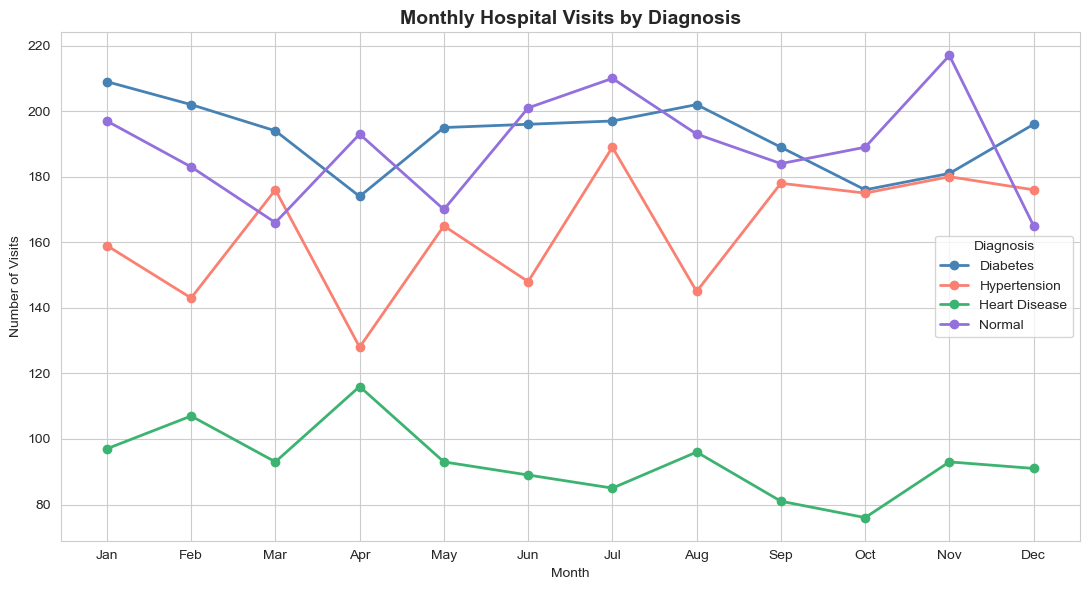

In [73]:
# Linechart - Monthly visits by Diagnosis

plt.figure(figsize=(11, 6))
MONTH_ORDER = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

# Diabetes
diabetes = df[df['diagnosis'] == 'Diabetes']['visit_month'].value_counts().reindex(MONTH_ORDER)
plt.plot(MONTH_ORDER, diabetes.values, marker='o',
         label='Diabetes', color='steelblue', linewidth=2)

# Hypertension
hypertension = df[df['diagnosis'] == 'Hypertension']['visit_month'].value_counts().reindex(MONTH_ORDER)
plt.plot(MONTH_ORDER, hypertension.values, marker='o',
         label='Hypertension', color='salmon', linewidth=2)

# Heart Disease
heart = df[df['diagnosis'] == 'Heart Disease']['visit_month'].value_counts().reindex(MONTH_ORDER)
plt.plot(MONTH_ORDER, heart.values, marker='o',
         label='Heart Disease', color='mediumseagreen', linewidth=2)

# Normal
normal = df[df['diagnosis'] == 'Normal']['visit_month'].value_counts().reindex(MONTH_ORDER)
plt.plot(MONTH_ORDER, normal.values, marker='o',
         label='Normal', color='mediumpurple', linewidth=2)

plt.title('Monthly Hospital Visits by Diagnosis',
          fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Number of Visits')
plt.legend(title='Diagnosis')
plt.tight_layout()
plt.show()

_Observation -> All four diagnosis lines fluctuate randomly across all 12 months
with no seasonal trend. Diabetes and Normal stay higher (180–220) due to
larger patient counts, Heart Disease stays lowest (80–120), and Hypertension
shows the sharpest month-to-month variation. This randomness is expected
since visit_month was randomly assigned during data generation._

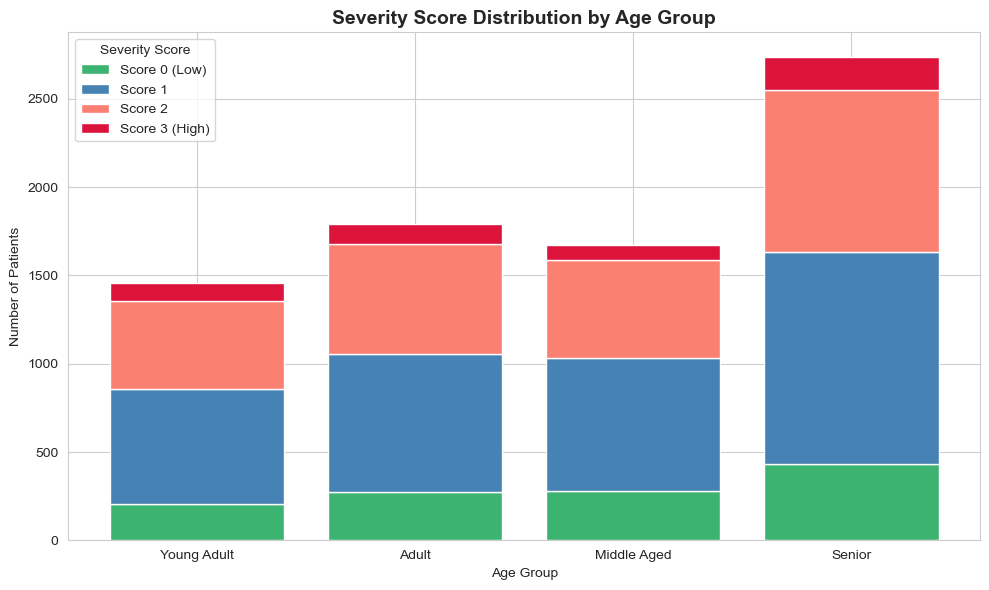

In [74]:
# Stacked Bar -  Severity Score vs age group

plt.figure(figsize=(10, 6))

AGE_ORDER = ['Young Adult', 'Adult', 'Middle Aged', 'Senior']

# Count each severity score per age group
score0 = df[df['severity_score'] == 0]['age_group'].value_counts().reindex(AGE_ORDER)
score1 = df[df['severity_score'] == 1]['age_group'].value_counts().reindex(AGE_ORDER)
score2 = df[df['severity_score'] == 2]['age_group'].value_counts().reindex(AGE_ORDER)
score3 = df[df['severity_score'] == 3]['age_group'].value_counts().reindex(AGE_ORDER)

# Plot each layer on top of previous
plt.bar(AGE_ORDER, score0.values,                                      color='mediumseagreen', label='Score 0 (Low)')
plt.bar(AGE_ORDER, score1.values, bottom=score0.values,                color='steelblue',      label='Score 1')
plt.bar(AGE_ORDER, score2.values, bottom=score0.values+score1.values,  color='salmon',         label='Score 2')
plt.bar(AGE_ORDER, score3.values, bottom=score0.values+score1.values+score2.values,
                                                                        color='crimson',        label='Score 3 (High)')

plt.title('Severity Score Distribution by Age Group',
          fontsize=14, fontweight='bold')
plt.xlabel('Age Group')
plt.ylabel('Number of Patients')
plt.legend(title='Severity Score')
plt.tight_layout()
plt.show()

_Observation -> Senior patients have the highest total count (~2700) and greatest
severity burden. Score 2 (salmon) dominates all age groups since most
randomly generated patients cross at least two of the three severity
thresholds. Score 0 is the smallest layer across every age group._

## _Conclusion_

This project performed Exploratory Data Analysis on a synthetically generated healthcare patient records dataset of 7,658 patients, covering the complete data analysis workflow — from data generation and cleaning to feature engineering and visualization.
Key findings from the analysis:

The dataset has a fairly uniform age distribution with a mean age of 51 years, covering all adult groups from 18 to 84.
Diabetes is the most common diagnosis (30%), followed by Normal (30%), Hypertension (25%), and Heart Disease (15%).
Treatment costs are uniformly spread between ₹5,000 and ₹2,00,000 with no significant difference across diagnosis types.
The correlation heatmap showed near-zero correlations between all numeric variables, confirming that features were generated independently.
Monthly hospital visits fluctuate randomly across all 12 months with no seasonal pattern for any diagnosis.
Senior patients carry the highest severity burden, with Score 2 being the most dominant severity level across all age groups.
High-risk patients (severity score ≥ 2) who were admitted accounted for a notable portion of the dataset, highlighting the potential value of severity scoring in real-world triage systems.

Overall, this project demonstrates a structured EDA approach on healthcare data — from raw generation to actionable visual insights — and lays the groundwork for future machine learning work on predicting hospital admissions.
